# **Industrial-health-index-PdM**
**Цель**: Развернуть готовую к производству систему прогнозирующего технического обслуживания, которая прогнозирует отказы подшипников на основе сигналов вибрации.

## Анализ датасета NASA IMS и план разработки модели RUL

### Ключевые характеристики датасета

**Общие параметры:**
* частота вращения: 2 000 об/мин;
* радиальная нагрузка: 6 000 фунтов;
* тип подшипников: Rexnord ZA‑2115 (двухрядные);
* смазка: принудительная;
* срок службы до отказа: более 100 млн оборотов;
* датчики: PCB 353B33 (акселерометры);
* частота дискретизации: 20 кГц;
* длительность записи: 1 с (20 480 точек);
* интервал между записями: 10 минут (в наборе 1 первые 43 файла — каждые 5 минут);
* формат файлов: ASCII.

**Структура наборов данных:**

| Набор | Длительность | Кол-во файлов | Каналы | Особенности отказа |
|------|-------------|--------------|--------|----------------|
| 1 | 22.10.2003–25.11.2003 | 2 156 | 8 (2 датчика на подшипник) | Внутренний дефект (подшипник 3), дефект ролика (подшипник 4) |
| 2 | 12.02.2004–19.02.2004 | 984 | 4 (1 датчик на подшипник) | Внешний дефект (подшипник 1) |
| 3 | 04.03.2004–04.04.2004 | 4 448 | 4 (1 датчик на подшипник) | Внешний дефект (подшипник 3) |

---

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import timedelta
import sys
import os


# Добавляем путь к папке src в sys.path
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

# Теперь импорт сработает
from features_engine import extract_advanced_features

# Определяем путь к данным
data_path = Path('../data/1st_test') 
# data_path = Path('../data/2nd_test')
# data_path = Path('../data/4th_test') 


In [43]:
import os

# Динамическое имя кэша на основе выбранного пути данных
# Например: если data_path это '../data/4th_test', cache_file станет '4th_test_features.pkl'
cache_file = f"{data_path.name}_features.pkl"

if os.path.exists(cache_file):
    print(f"🚀 Нашел кеш для {data_path.name}! Загружаю данные...")
    df_features = pd.read_pickle(cache_file)
else:
    print(f"📦 Кеш не найден. Запускаю извлечение признаков для {data_path.name}...")
    df_features = extract_advanced_features(data_path)
    
    # Расчет медианы и ratio
    rms_cols = [c for c in df_features.columns if c.endswith('_rms') and 'median' not in c]
    df_features['rms_median'] = df_features[rms_cols].median(axis=1)
    
    for col in rms_cols:
        bearing_id = col.split('_')[0]
        df_features[f'{bearing_id}_rms_ratio'] = df_features[col] / df_features['rms_median']
    
    # Сохраняем результат
    df_features.to_pickle(cache_file)
    print(f"✅ Обработка завершена. Данные сохранены в {cache_file}")

print(f"📊 В работе {len(df_features)} точек данных для датасета {data_path.name}.")

🚀 Нашел кеш для 1st_test! Загружаю данные...
📊 В работе 2156 точек данных для датасета 1st_test.


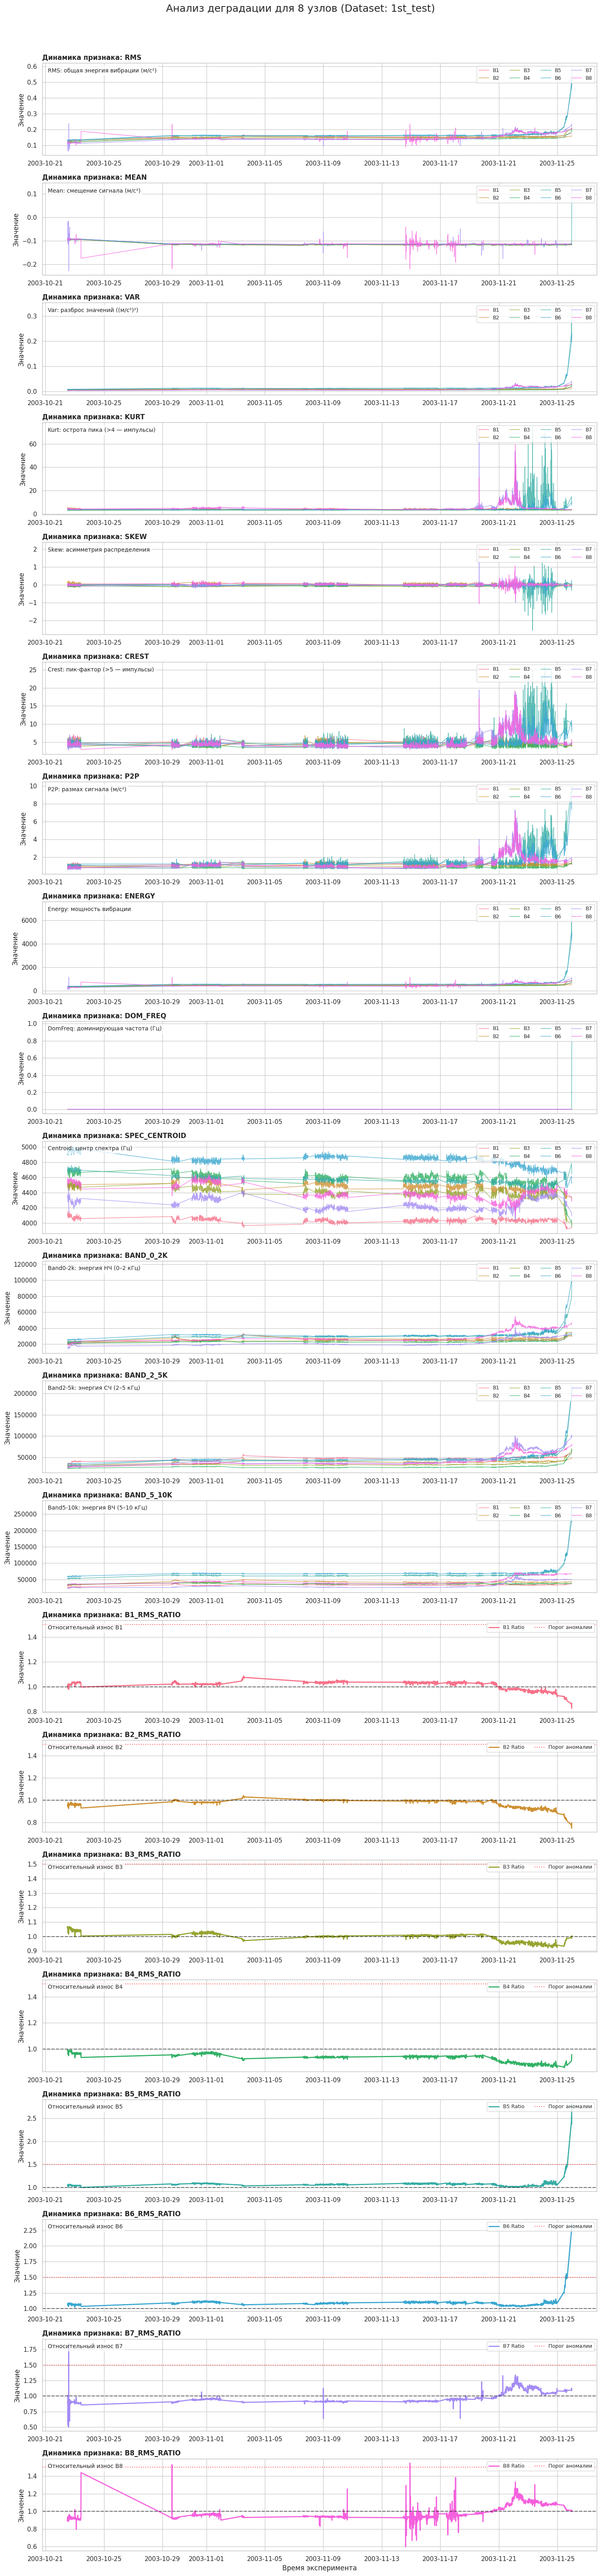

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Автоматически определяем доступные подшипники и базовые признаки
# Находим все колонки, заканчивающиеся на _rms (кроме median)
bearing_ids = sorted(list(set(c.split('_')[0] for c in df_features.columns if c.endswith('_rms') and 'median' not in c)))

# Базовые признаки (без префикса b1_, b2_ и т.д.)
base_features = ['rms', 'mean', 'var', 'kurt', 'skew', 'crest', 'p2p',
                 'energy', 'dom_freq', 'spec_centroid', 'band_0_2k',
                 'band_2_5k', 'band_5_10k']

# Формируем итоговый список графиков: сначала общие признаки, потом ratio для каждого подшипника
plot_features = base_features + [f'{b}_rms_ratio' for b in bearing_ids]

# 2. Расширенный словарь описаний (базовый)
feature_desc_base = {
    'rms': 'RMS: общая энергия вибрации (м/с²)',
    'mean': 'Mean: смещение сигнала (м/с²)',
    'var': 'Var: разброс значений ((м/с²)²)',
    'kurt': 'Kurt: острота пика (>4 — импульсы)',
    'skew': 'Skew: асимметрия распределения',
    'crest': 'Crest: пик‑фактор (>5 — импульсы)',
    'p2p': 'P2P: размах сигнала (м/с²)',
    'energy': 'Energy: мощность вибрации',
    'dom_freq': 'DomFreq: доминирующая частота (Гц)',
    'spec_centroid': 'Centroid: центр спектра (Гц)',
    'band_0_2k': 'Band0‑2k: энергия НЧ (0–2 кГц)',
    'band_2_5k': 'Band2‑5k: энергия СЧ (2–5 кГц)',
    'band_5_10k': 'Band5‑10k: энергия ВЧ (5–10 кГц)'
}

# 3. Настройка стиля и создание полотна
sns.set_theme(style="whitegrid")
n_rows = len(plot_features)
fig, axes = plt.subplots(n_rows, 1, figsize=(15, n_rows * 3))
if n_rows == 1: axes = [axes] # Защита от случая с 1 графиком

fig.suptitle(f'Анализ деградации для {len(bearing_ids)} узлов (Dataset: {data_path.name})', 
             fontsize=18, y=1.01)

# Цветовая палитра для подшипников
colors = sns.color_palette("husl", len(bearing_ids))

# 4. Цикл отрисовки
for idx, feature in enumerate(plot_features):
    ax = axes[idx]
    
    if feature.endswith('_rms_ratio'):
        # Рисуем график Ratio для конкретного подшипника
        bearing_label = feature.replace('_rms_ratio', '')
        b_idx = bearing_ids.index(bearing_label)
        
        ax.plot(df_features['timestamp'], df_features[feature],
                label=f'{bearing_label.upper()} Ratio', 
                color=colors[b_idx], linewidth=2)
        
        ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
        # Добавляем порог детекции (если есть)
        ax.axhline(y=1.5, color='red', linestyle=':', alpha=0.6, label='Порог аномалии')
        
        desc = f"Относительный износ {bearing_label.upper()}"
    else:
        # Рисуем базовый признак для всех подшипников сразу
        for b_idx, b_id in enumerate(bearing_ids):
            col_name = f'{b_id}_{feature}'
            if col_name in df_features.columns:
                ax.plot(df_features['timestamp'], df_features[col_name],
                        label=f'{b_id.upper()}', color=colors[b_idx], alpha=0.8, linewidth=1)
        
        desc = feature_desc_base.get(feature, feature)

    # Оформление каждого подобъекта
    ax.set_title(f"Динамика признака: {feature.upper()}", loc='left', fontsize=12, fontweight='bold')
    ax.text(0.01, 0.95, desc, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    ax.legend(loc='upper right', ncol=min(4, len(bearing_ids)), fontsize=9)
    ax.set_ylabel("Значение")

plt.xlabel('Время эксперимента', fontsize=12)
plt.tight_layout()
plt.show()

In [45]:


# --- 1. ОПРЕДЕЛЕНИЯ ФУНКЦИЙ ---

def detect_fpt_and_failures_final(df: pd.DataFrame, baseline_files: int = 500, sigma_mult: float = 5.0):
    """
    Финальная версия детектора:
    - Адаптивное окно подтверждения (sustained_threshold)
    - Физический 'предохранитель' (если ratio > 3.0, это авария)
    - Проверка 'активности' дефекта в самом конце данных
    """
    # Динамический поиск колонок с RMS
    rms_cols = [c for c in df.columns if c.endswith('_rms') and 'median' not in c]
    bearings = [c.split('_')[0] for c in rms_cols]
    
    # Расчет медианы и отношения (ratio)
    df['rms_median'] = df[rms_cols].median(axis=1)
    for b in bearings:
        df[f'{b}_rms_ratio'] = df[f'{b}_rms'] / df['rms_median']
        
    fpt_results = {}
    
    for b in bearings:
        target_col = f'{b}_rms_ratio'
        # Защита: базовый период не может быть больше 1/4 всего датасета
        safe_baseline = min(baseline_files, len(df) // 4) 
        
        mu = df[target_col].iloc[:safe_baseline].mean()
        sigma = df[target_col].iloc[:safe_baseline].std()
        
        # Порог: либо статистика (сигмы), либо физика (минимум 1.5)
        threshold = max(mu + sigma_mult * sigma, 1.5)
        
        # Сглаживание для исключения шума
        smoothed = df[target_col].rolling(window=5, min_periods=1).mean()
        breaches = smoothed > threshold
        
        if breaches.any():
            # 1. Критическая авария (очень высокий уровень)
            is_critical = (smoothed > 3.0).any()
            
            # 2. Устойчивый тренд (адаптивное окно подтверждения)
            confirm_window = min(15, max(3, int(len(df) * 0.005)))
            sustained = breaches.rolling(window=confirm_window).mean() >= 0.6
            
            if sustained.any() or is_critical:
                first_idx = breaches[breaches].index[0]
                fpt_time = df['timestamp'].iloc[first_idx]
                
                # Проверка: не "зажил" ли подшипник в конце?
                is_active_now = (smoothed.iloc[-5:] > threshold).any()
                
                if is_active_now or is_critical:
                    fpt_results[b] = {'fpt_time': fpt_time, 'is_failing': True}
                else:
                    fpt_results[b] = {'is_failing': False, 'reason': 'Всплеск угас'}
            else:
                fpt_results[b] = {'is_failing': False, 'reason': 'Недостаточно данных для тренда'}
        else:
            fpt_results[b] = {'is_failing': False, 'reason': 'Тренд в норме'}

    
            
    # Печать красивого отчета
    print(f"\n📊 ИТОГОВЫЙ ОТЧЕТ ПО УЗЛАМ ({len(bearings)} шт.):")
    failing_bearings = []
    for b, res in fpt_results.items():
        if res['is_failing']:
            print(f"⚠️ {b.upper()}: ДЕГРАДАЦИЯ! Начало (FPT): {res['fpt_time']}")
            failing_bearings.append(b)
        else:
            print(f"✅ {b.upper()}: OK ({res['reason']})")
            
    return df, fpt_results, failing_bearings


# --- 2. ЛОГИКА ЗАПУСКА (MAIN) ---

# Шаг 1: Выбор данных (раскомментируй нужный)
# data_path = Path('../data/1st_test') 
# data_path = Path('../data/2nd_test')
# data_path = Path('../data/4th_test') 

print(f"🚀 Запуск обработки для: {data_path.name}")

# --- НОВЫЙ БЛОК: УМНАЯ ЗАГРУЗКА ИЗ КЭША ---
cache_file = f"{data_path.name}_features.pkl"

if os.path.exists(cache_file):
    print(f"📦 Нашел кэш! Мгновенная загрузка из {cache_file}...")
    df_features = pd.read_pickle(cache_file)
else:
    print(f"🧪 Кэш не найден. Начинаем извлечение признаков (это может занять время)...")
    # Шаг 2: Извлечение признаков через твой движок
    df_features = extract_advanced_features(data_path)
    
    # Сразу рассчитываем базовые ratio, чтобы они сохранились в кэш
    rms_cols = [c for c in df_features.columns if c.endswith('_rms') and 'median' not in c]
    df_features['rms_median'] = df_features[rms_cols].median(axis=1)
    for col in rms_cols:
        bearing_id = col.split('_')[0]
        df_features[f'{bearing_id}_rms_ratio'] = df_features[col] / df_features['rms_median']
    
    # Сохраняем в кэш для следующего раза
    df_features.to_pickle(cache_file)
    print(f"✅ Признаки извлечены и сохранены в кэш: {cache_file}")

# --- КОНЕЦ БЛОКА КЭШИРОВАНИЯ ---

# Шаг 3: Детекция FPT
df_features, fpt_results, failing_bearings = detect_fpt_and_failures_final(
    df_features, 
    baseline_files=300 if '1st' in data_path.name else 500,
    sigma_mult=5.0
)

# Шаг 4: Прогноз RUL (функции predict_rul_exponential и остальные должны быть определены выше)
print("\n🔮 ПРОГНОЗ ОСТАТОЧНОГО РЕСУРСА (RUL):")
if not failing_bearings:
    print("✅ Все узлы в норме. Прогноз не требуется.")
else:
    for b in failing_bearings:
        fpt_info = fpt_results[b]
        rul, model_params = predict_rul_exponential(
            df_features, 
            b, 
            fpt_info['fpt_time'], 
            failure_threshold=4.5
        )
        
        if isinstance(rul, (int, float)):
            print(f"⏳ {b.upper()}: До критического отказа осталось примерно {rul:.2f} ч.")
        else:
            print(f"ℹ️ {b.upper()}: Прогноз не построен ({model_params})")




🚀 Запуск обработки для: 1st_test
📦 Нашел кэш! Мгновенная загрузка из 1st_test_features.pkl...

📊 ИТОГОВЫЙ ОТЧЕТ ПО УЗЛАМ (8 шт.):
✅ B1: OK (Тренд в норме)
✅ B2: OK (Тренд в норме)
✅ B3: OK (Тренд в норме)
✅ B4: OK (Тренд в норме)
✅ B5: OK (Недостаточно данных для тренда)
⚠️ B6: ДЕГРАДАЦИЯ! Начало (FPT): 2003-11-25 14:37:32
✅ B7: OK (Тренд в норме)
✅ B8: OK (Тренд в норме)

🔮 ПРОГНОЗ ОСТАТОЧНОГО РЕСУРСА (RUL):
⏳ B6: До критического отказа осталось примерно 30.40 ч.



🔮 ЗАПУСК МАТЕМАТИЧЕСКОГО ПРОГНОЗА:


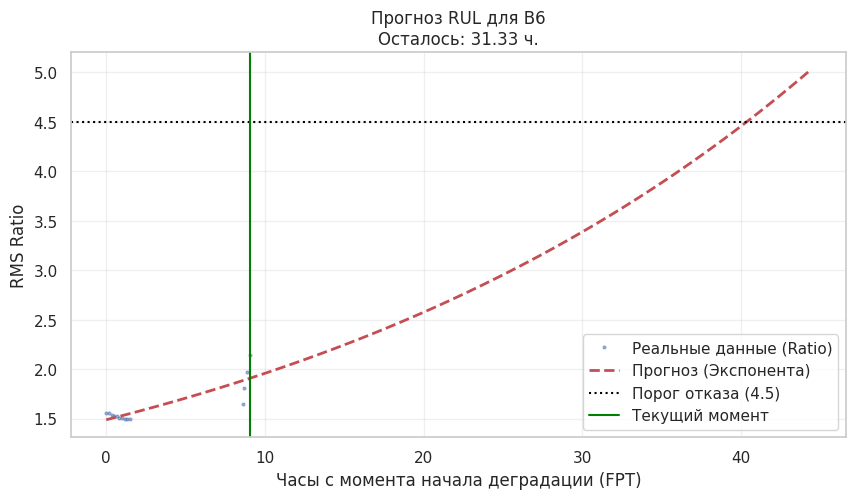

🎯 Итог для B6: Рекомендуемая замена через 31.33 ч.


In [51]:
from scipy.optimize import curve_fit

# --- 1. ФУНКЦИЯ ПРЕДСКАЗАНИЯ RUL ---

def exponential_model(x, a, b):
    """Математическая модель: экспоненциальный рост деградации"""
    return a * np.exp(b * x)

def predict_rul_exponential_with_plot(df, bearing_name, fpt_time, failure_threshold=4.5):
    """
    Рассчитывает RUL и рисует график прогноза.
    """
    # 1. Подготовка данных (как и раньше)
    degradation_phase = df[df['timestamp'] >= fpt_time].copy()
    if len(degradation_phase) < 10:
        return None, "Мало данных"

    start_ts = degradation_phase['timestamp'].min()
    degradation_phase['hours_passed'] = (degradation_phase['timestamp'] - start_ts).dt.total_seconds() / 3600
    
    x_data = degradation_phase['hours_passed'].values
    y_data = degradation_phase[f'{bearing_name}_rms_ratio'].rolling(window=5, min_periods=1).mean().bfill().values

    try:
        # 2. Обучение модели
        popt, _ = curve_fit(exponential_model, x_data, y_data, p0=[0.1, 0.05], maxfev=2000)
        a, b = popt

        if b <= 0: return None, "Тренд стабилен"

        # 3. Расчет RUL
        total_hours_to_failure = np.log(failure_threshold / a) / b
        current_hours = x_data[-1]
        rul_hours = max(0, total_hours_to_failure - current_hours)

        # --- БЛОК ВИЗУАЛИЗАЦИИ ---
        plt.figure(figsize=(10, 5))
        # Рисуем реальные точки (Ratio)
        plt.plot(x_data, y_data, 'bo', label='Реальные данные (Ratio)', markersize=2, alpha=0.5)
        
        # Строим кривую предсказания (чуть дальше в будущее)
        x_future = np.linspace(0, total_hours_to_failure * 1.1, 100)
        y_future = exponential_model(x_future, a, b)
        plt.plot(x_future, y_future, 'r--', label='Прогноз (Экспонента)', linewidth=2)

        # Линия порога аварии
        plt.axhline(y=failure_threshold, color='black', linestyle=':', label='Порог отказа (4.5)')
        # Точка текущего момента
        plt.axvline(x=current_hours, color='green', label='Текущий момент')
        
        plt.title(f"Прогноз RUL для {bearing_name.upper()}\nОсталось: {rul_hours:.2f} ч.")
        plt.xlabel("Часы с момента начала деградации (FPT)")
        plt.ylabel("RMS Ratio")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        # ------------------------

        return rul_hours, (a, b)

    except Exception as e:
        return None, f"Ошибка: {e}"
    
print("\n🔮 ЗАПУСК МАТЕМАТИЧЕСКОГО ПРОГНОЗА:")

if not failing_bearings:
    print("✅ Все узлы в норме, предсказывать нечего.")
else:
    for b in failing_bearings:
        fpt_info = fpt_results[b]
        
        # Вызываем обновленную функцию с графиком
        rul, params = predict_rul_exponential_with_plot(
            df_features, 
            b, 
            fpt_info['fpt_time'], 
            failure_threshold=4.5
        )
        
        if rul is not None:
            print(f"🎯 Итог для {b.upper()}: Рекомендуемая замена через {rul:.2f} ч.")   